In [ ]:
import pandas as pd
import requests
import json
import tiktoken
import time
import re
import glob # Para encontrar arquivos em um diretório
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

API_KEY = ""

In [3]:

# Configuração da API
url = "https://api.deepseek.com/v1/chat/completions"
MODEL = "deepseek-chat"

HEADERS = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json"
}


LIMITE_MODELO = 8000
EST_SAIDA_POR_ITEM = 5
TEMPERATURE = 0.0
TOP_P = 1.0



In [4]:
# === CONFIGURAÇÕES GERAIS ===
PROMPT_FIXO = "Classifique os textos a seguir em 0 (não preconceito) ou 1 (preconceito). Não precisa de explicação, apenas rotule.\n"


# Inicializa o codificador
#enc = tiktoken.encoding_for_model(MODEL)
enc = tiktoken.get_encoding("cl100k_base")
TOKENS_PROMPT_FIXO = len(enc.encode(PROMPT_FIXO))


# === FUNÇÕES AUXILIARES ===
def contar_tokens_string(s: str) -> int:
    return len(enc.encode(s or ""))


def estimar_tokens_lote(itens):
    """Estima tokens de um lote."""
    total = TOKENS_PROMPT_FIXO
    for i, (_, t) in enumerate(itens):
        total += contar_tokens_string(f"{i}: {t}")
    total += len(itens) * EST_SAIDA_POR_ITEM
    return total


def split_em_lotes(df_textos, limite=LIMITE_MODELO):
    """Divide DataFrame em lotes respeitando o limite de tokens."""
    lotes, lote = [], []
    for _, row in df_textos.iterrows():
        id_val = str(row["id"])
        texto = str(row["text_content_anonymous"])
        if estimar_tokens_lote(lote + [(id_val, texto)]) <= limite:
            lote.append((id_val, texto))
        else:
            if lote:
                lotes.append(lote)
            lote = [(id_val, texto)]
            # Trunca texto se mesmo isolado for muito grande
            if estimar_tokens_lote(lote) > limite:
                trunc = enc.decode(enc.encode(texto)[:2048])
                lote = [(id_val, trunc)]
    if lote:
        lotes.append(lote)
    return lotes


def extrair_json_da_resposta(texto_resposta: str):
    """Extrai JSON da resposta do modelo."""
    try:
        start, end = texto_resposta.find("{"), texto_resposta.rfind("}")
        if start != -1 and end != -1 and end > start:
            return json.loads(texto_resposta[start:end + 1])
        return json.loads(texto_resposta)
    except Exception:
        return None


def enviar_lote(lote, prompt_base, max_tokens=1024):
    prompt = prompt_base + "".join(f"\n{i}: {t}" for i, (_, t) in enumerate(lote))
    prompt += '\n\nResponda no formato JSON, onde cada índice corresponde ao rótulo. Exemplo: {"0": 0, "1": 1}\n'

    body = {
        "model": MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "max_tokens": max_tokens,
        "temperature": TEMPERATURE,
        "top_p": TOP_P
    }

    return requests.post(
        url,  # <- aqui usa a nova URL
        headers=HEADERS,
        data=json.dumps(body),
        timeout=120
    )

# === FUNÇÃO PRINCIPAL ===
def processar_arquivo(csv_entrada, csv_saida, prompt_base, log_nome):
    """Processa um arquivo CSV em lotes."""
    inicio = time.time()
    print(f"\nProcessando {csv_entrada} -> {csv_saida}")

    df = pd.read_csv(csv_entrada, dtype=str, encoding="utf-8", keep_default_na=False)
    df = df[df["text_content_anonymous"].str.strip() != ""].reset_index(drop=True)
    lotes = split_em_lotes(df)
    resultados = []

    # contadores de tokens
    total_prompt_tokens = total_completion_tokens = total_total_tokens = 0

    for i, lote in enumerate(lotes, start=1):
        print(f"Lote {i}/{len(lotes)} - {len(lote)} textos")
        max_tokens_saida = max(200, len(lote) * 8)

        try:
            resp = enviar_lote(lote, prompt_base, max_tokens=max_tokens_saida)
        except Exception as e:
            print("Erro na requisição HTTP:", e)
            resultados += [[id_val, texto, "ERRO_REQ"] for id_val, texto in lote]
            continue

        if resp.status_code != 200:
            print(f"Erro HTTP {resp.status_code}")
            resultados += [[id_val, texto, f"HTTP_{resp.status_code}"] for id_val, texto in lote]
            continue

        saida = resp.json()
        saida_texto = saida["choices"][0]["message"]["content"]
        rotulos_dict = extrair_json_da_resposta(saida_texto)

        usage = saida.get("usage", {})
        total_prompt_tokens += usage.get("prompt_tokens", 0)
        total_completion_tokens += usage.get("completion_tokens", 0)
        total_total_tokens += usage.get("total_tokens", 0)

        if not rotulos_dict:
            resultados += [[id_val, texto, "ERRO_PARSE"] for id_val, texto in lote]
            continue

        for idx, (id_val, texto) in enumerate(lote):
            rot = str(rotulos_dict.get(str(idx), "")).strip()
            if rot not in ("0", "1"):
                rot = "ERRO_VAL" if rot else "ERRO_NA_CHAVE"
            resultados.append([id_val, texto, rot])

        time.sleep(0.4)

    # salva resultados
    pd.DataFrame(resultados, columns=["id", "text_content_anonymous", "rotulo_modelo"]).to_csv(csv_saida, index=False, encoding="utf-8")
    print("Arquivo salvo em", csv_saida)

    duracao_min = (time.time() - inicio) / 60
    with open(log_nome, "a", encoding="utf-8") as f:
        f.write(
            f"{csv_entrada} -> {csv_saida} | Tempo: {duracao_min:.2f} min | "
            f"Prompt tokens: {total_prompt_tokens} | Saída tokens: {total_completion_tokens} | Total tokens: {total_total_tokens}\n"
        )

    print(f"Tempo total: {duracao_min:.2f} min | Tokens total: {total_total_tokens}")






In [5]:
# === EXECUÇÃO ZERO-SHOT ===
inicio_total = time.time()
for i in range(1, 13):
    entrada = f"../datasets/telegram/parte_{i}_telegram.csv"
    saida = f"./resultados/telegram/zero_shot_parte_{i}.csv"
    processar_arquivo(entrada, saida, PROMPT_FIXO, "./resultados/telegram/zeroShot_log_processamento_telegram.txt")
total_minutos = (time.time() - inicio_total) / 60
with open("./resultados/telegram/zeroShot_tempo_execucao_telegram.txt", "a", encoding="utf-8") as f:
    f.write(f"\nTempo total de execução: {total_minutos:.2f} minutos\n")



Processando ../datasets/telegram/parte_1_telegram.csv -> ./resultados/telegram/zero_shot_parte_1.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/zero_shot_parte_1.csv
Tempo total: 0.23 min | Tokens total: 5736

Processando ../datasets/telegram/parte_2_telegram.csv -> ./resultados/telegram/zero_shot_parte_2.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/zero_shot_parte_2.csv
Tempo total: 0.24 min | Tokens total: 5780

Processando ../datasets/telegram/parte_3_telegram.csv -> ./resultados/telegram/zero_shot_parte_3.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/zero_shot_parte_3.csv
Tempo total: 0.24 min | Tokens total: 4796

Processando ../datasets/telegram/parte_4_telegram.csv -> ./resultados/telegram/zero_shot_parte_4.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/zero_shot_parte_4.csv
Tempo total: 0.25 min | Tokens total: 4909

Processando ../datasets/telegram/parte_5_telegram.csv -> ./resultados/telegram/zero_shot_pa

In [6]:
# === EXECUÇÃO FEW-SHOT ===
with open("../datasets/telegram/few_shot.txt", "r", encoding="utf-8") as f:
    PROMPT_FEW = f.read()

inicio_total = time.time()
for i in range(1, 13):
    entrada = f"../datasets/telegram/parte_{i}_telegram.csv"
    saida = f"./resultados/telegram/few_shot_parte_{i}.csv"
    processar_arquivo(entrada, saida, PROMPT_FEW, "./resultados/telegram/fewShot_log_processamento_telegram.txt")
total_minutos = (time.time() - inicio_total) / 60
with open("./resultados/telegram/fewShot_tempo_execucao_telegram.txt", "a", encoding="utf-8") as f:
    f.write(f"\nTempo total de execução: {total_minutos:.2f} minutos\n")



Processando ../datasets/telegram/parte_1_telegram.csv -> ./resultados/telegram/few_shot_parte_1.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/few_shot_parte_1.csv
Tempo total: 0.23 min | Tokens total: 7123

Processando ../datasets/telegram/parte_2_telegram.csv -> ./resultados/telegram/few_shot_parte_2.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/few_shot_parte_2.csv
Tempo total: 0.23 min | Tokens total: 7167

Processando ../datasets/telegram/parte_3_telegram.csv -> ./resultados/telegram/few_shot_parte_3.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/few_shot_parte_3.csv
Tempo total: 0.20 min | Tokens total: 6127

Processando ../datasets/telegram/parte_4_telegram.csv -> ./resultados/telegram/few_shot_parte_4.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/few_shot_parte_4.csv
Tempo total: 0.25 min | Tokens total: 6296

Processando ../datasets/telegram/parte_5_telegram.csv -> ./resultados/telegram/few_shot_parte_5.csv

In [7]:
# === EXECUÇÃO Role Prompting  (Especialista em discurso preconceituoso) ===
with open("../datasets/prompt_role_prompting.txt", "r", encoding="utf-8") as f:
    PROMPT_ROLE = f.read()

inicio_total = time.time()
for i in range(1, 13):
    entrada = f"../datasets/telegram/parte_{i}_telegram.csv"
    saida = f"./resultados/telegram/prompt_role_prompting_parte_{i}.csv"
    processar_arquivo(entrada, saida, PROMPT_ROLE, "./resultados/telegram/role_prompting_log_processamento.txt")
total_minutos = (time.time() - inicio_total) / 60
with open("./resultados/telegram/prompt_role_prompting_tempo_execucao_telegram.txt", "a", encoding="utf-8") as f:
    f.write(f"\nTempo total de execução: {total_minutos:.2f} minutos\n")



Processando ../datasets/telegram/parte_1_telegram.csv -> ./resultados/telegram/prompt_role_prompting_parte_1.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/prompt_role_prompting_parte_1.csv
Tempo total: 0.24 min | Tokens total: 5888

Processando ../datasets/telegram/parte_2_telegram.csv -> ./resultados/telegram/prompt_role_prompting_parte_2.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/prompt_role_prompting_parte_2.csv
Tempo total: 0.26 min | Tokens total: 5932

Processando ../datasets/telegram/parte_3_telegram.csv -> ./resultados/telegram/prompt_role_prompting_parte_3.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/prompt_role_prompting_parte_3.csv
Tempo total: 0.23 min | Tokens total: 4948

Processando ../datasets/telegram/parte_4_telegram.csv -> ./resultados/telegram/prompt_role_prompting_parte_4.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/prompt_role_prompting_parte_4.csv
Tempo total: 0.23 min | Tokens total: 5

In [8]:
# === EXECUÇÃO DIC_COMPLETO  ===
with open("../datasets/dicionario_socialliwc.txt", "r", encoding="utf-8") as f:
    PROMPT_DIC = f.read()

inicio_total = time.time()
for i in range(1, 13):
    entrada = f"../datasets/telegram/parte_{i}_telegram.csv"
    saida = f"./resultados/telegram/prompt_dicionario_parte_{i}.csv"
    processar_arquivo(entrada, saida, PROMPT_DIC, "./resultados/telegram/prompt_dicionario_log_processamento.txt")
total_minutos = (time.time() - inicio_total) / 60
with open("./resultados/telegram/prompt_dicionario_tempo_execucao_telegram.txt", "a", encoding="utf-8") as f:
    f.write(f"\nTempo total de execução: {total_minutos:.2f} minutos\n")



Processando ../datasets/telegram/parte_1_telegram.csv -> ./resultados/telegram/prompt_dicionario_parte_1.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/prompt_dicionario_parte_1.csv
Tempo total: 0.22 min | Tokens total: 9680

Processando ../datasets/telegram/parte_2_telegram.csv -> ./resultados/telegram/prompt_dicionario_parte_2.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/prompt_dicionario_parte_2.csv
Tempo total: 0.21 min | Tokens total: 9668

Processando ../datasets/telegram/parte_3_telegram.csv -> ./resultados/telegram/prompt_dicionario_parte_3.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/prompt_dicionario_parte_3.csv
Tempo total: 0.23 min | Tokens total: 8740

Processando ../datasets/telegram/parte_4_telegram.csv -> ./resultados/telegram/prompt_dicionario_parte_4.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/prompt_dicionario_parte_4.csv
Tempo total: 0.22 min | Tokens total: 8853

Processando ../datasets/tel

## Processamento - Zero Shot

In [9]:
# Junção dos dados

all_files = glob.glob("./resultados/telegram/zero_shot*.csv") 

li = []

for filename in all_files:
    df = pd.read_csv(filename) # Lê cada arquivo CSV
    li.append(df) # Adiciona o DataFrame lido à lista

# Concatena todos os DataFrames em um único DataFrame
final_df = pd.concat(li, axis=0, ignore_index=False) # axis=0 para empilhar as linhas
                                                    # ignore_index = False mantem o index original

print(f"Total de {len(all_files)} arquivos combinados.")
print(f"O DataFrame final tem {final_df.shape[0]} linhas e {final_df.shape[1]} colunas.")

# Para salvar o DataFrame combinado em um novo arquivo CSV
final_df.to_csv("./resultados/telegram/arquivo_combinado_zeroShot_telegram.csv", index=False)
print("Arquivo 'arquivo_combinado_zeroShot_telegram.csv' criado com sucesso!")

Total de 12 arquivos combinados.
O DataFrame final tem 600 linhas e 3 colunas.
Arquivo 'arquivo_combinado_zeroShot_telegram.csv' criado com sucesso!


In [10]:
df_combinado = pd.read_csv('./resultados/telegram/arquivo_combinado_zeroShot_telegram.csv')
df_combinado.head()

,id,text_content_anonymous,rotulo_modelo
0,481,Todos que são do Bolsonaro sai imediatamente d...,1
1,2588,"Eu confesso, não tenho paciência com os parent...",1
2,2663,"Isentão você desceu do muro, agora está do lad...",1
3,522,"Acho q o canal no telegram q foi bloqueado,pq ...",0
4,582,"Meu Deus a mídia sempre foi nossa inimiga, um ...",1


In [11]:
df_combinado['rotulo_modelo'].value_counts()

rotulo_modelo
1    340
0    260
Name: count, dtype: int64

In [12]:
# Junção com o arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/telegram/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/telegram/arquivo_combinado_zeroShot_telegram.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_chatgpt'
df_llm = df_llm.rename(columns={"rotulo_modelo": "rotulo_chatgpt"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_chatgpt"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/telegram/telegram_comparado_zeroShot.csv", index=False, encoding="utf-8")

print("✅ Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


✅ Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


## Processamento - Few Shot

In [13]:
# Junção dos dados

all_files = glob.glob("./resultados/telegram/few_shot_parte*.csv") 

li = []

for filename in all_files:
    df = pd.read_csv(filename) # Lê cada arquivo CSV
    li.append(df) # Adiciona o DataFrame lido à lista

# Concatena todos os DataFrames em um único DataFrame
final_df = pd.concat(li, axis=0, ignore_index=False) # axis=0 para empilhar as linhas
                                                    # ignore_index = False mantem o index original

print(f"Total de {len(all_files)} arquivos combinados.")
print(f"O DataFrame final tem {final_df.shape[0]} linhas e {final_df.shape[1]} colunas.")

# Para salvar o DataFrame combinado em um novo arquivo CSV
final_df.to_csv("./resultados/telegram/arquivo_combinado_fewShot_telegram.csv", index=False)
print("Arquivo 'arquivo_combinado_fewShot_telegram.csv' criado com sucesso!")

Total de 12 arquivos combinados.
O DataFrame final tem 600 linhas e 3 colunas.
Arquivo 'arquivo_combinado_fewShot_telegram.csv' criado com sucesso!


In [14]:
final_df['rotulo_modelo'].value_counts()

rotulo_modelo
0    378
1    222
Name: count, dtype: int64

In [15]:
# Junção com o arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/telegram/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/telegram/arquivo_combinado_fewShot_telegram.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_chatgpt'
df_llm = df_llm.rename(columns={"rotulo_modelo": "rotulo_chatgpt"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_chatgpt"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/telegram/telegram_comparado_fewShot.csv", index=False, encoding="utf-8")

print("✅ Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


✅ Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


## Processamento Role Prompting

In [16]:
# Junção de arquivos 

all_files = glob.glob("./resultados/telegram/prompt_role_prompting*.csv") 

li = []

for filename in all_files:
    df = pd.read_csv(filename) # Lê cada arquivo CSV
    li.append(df) # Adiciona o DataFrame lido à lista

# Concatena todos os DataFrames em um único DataFrame
final_df = pd.concat(li, axis=0, ignore_index=False) # axis=0 para empilhar as linhas
                                                    # ignore_index = False mantem o index original

print(f"Total de {len(all_files)} arquivos combinados.")
print(f"O DataFrame final tem {final_df.shape[0]} linhas e {final_df.shape[1]} colunas.")

# Para salvar o DataFrame combinado em um novo arquivo CSV
final_df.to_csv("./resultados/telegram/arquivo_combinado_role_prompting_telegram.csv", index=False)
print("Arquivo 'arquivo_combinado_role_prompting_telegram.csv' criado com sucesso!")

Total de 12 arquivos combinados.
O DataFrame final tem 600 linhas e 3 colunas.
Arquivo 'arquivo_combinado_role_prompting_telegram.csv' criado com sucesso!


In [17]:
final_df = pd.read_csv('./resultados/telegram/arquivo_combinado_role_prompting_telegram.csv')
final_df.head()

,id,text_content_anonymous,rotulo_modelo
0,481,Todos que são do Bolsonaro sai imediatamente d...,1
1,2588,"Eu confesso, não tenho paciência com os parent...",1
2,2663,"Isentão você desceu do muro, agora está do lad...",1
3,522,"Acho q o canal no telegram q foi bloqueado,pq ...",0
4,582,"Meu Deus a mídia sempre foi nossa inimiga, um ...",0


In [18]:
final_df['rotulo_modelo'].value_counts()

rotulo_modelo
1    340
0    260
Name: count, dtype: int64

In [19]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/telegram/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/telegram/arquivo_combinado_role_prompting_telegram.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_chatgpt'
df_llm = df_llm.rename(columns={"rotulo_modelo": "rotulo_chatgpt"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_chatgpt"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/telegram/telegram_comparado_role_prompting.csv", index=False, encoding="utf-8")

print(" Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


 Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


## Processamento Dicionário

In [20]:
# Junção de arquivos 

all_files = glob.glob("./resultados/telegram/prompt_dicionario_*.csv") 

li = []

for filename in all_files:
    df = pd.read_csv(filename) # Lê cada arquivo CSV
    li.append(df) # Adiciona o DataFrame lido à lista

# Concatena todos os DataFrames em um único DataFrame
final_df = pd.concat(li, axis=0, ignore_index=False) # axis=0 para empilhar as linhas
                                                    # ignore_index = False mantem o index original

print(f"Total de {len(all_files)} arquivos combinados.")
print(f"O DataFrame final tem {final_df.shape[0]} linhas e {final_df.shape[1]} colunas.")

# Para salvar o DataFrame combinado em um novo arquivo CSV
final_df.to_csv("./resultados/telegram/arquivo_combinado_dicionario_telegram.csv", index=False)
print("Arquivo 'arquivo_combinado_dicionario_telegram.csv' criado com sucesso!")

Total de 12 arquivos combinados.
O DataFrame final tem 600 linhas e 3 colunas.
Arquivo 'arquivo_combinado_dicionario_telegram.csv' criado com sucesso!


In [21]:
final_df['rotulo_modelo'].value_counts()

rotulo_modelo
0    321
1    279
Name: count, dtype: int64

In [22]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/telegram/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/telegram/arquivo_combinado_dicionario_telegram.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_chatgpt'
df_llm = df_llm.rename(columns={"rotulo_modelo": "rotulo_chatgpt"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_chatgpt"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/telegram/telegram_comparado_dicionario.csv", index=False, encoding="utf-8")

print(" Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


 Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


## Calculando métricas

### Zero Shot


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.7906 ± 0.0169
Precision: 0.7566 ± 0.0233
Recall: 0.8575 ± 0.0196
F1: 0.8037 ± 0.0172
Auc: 0.7905 ± 0.0168


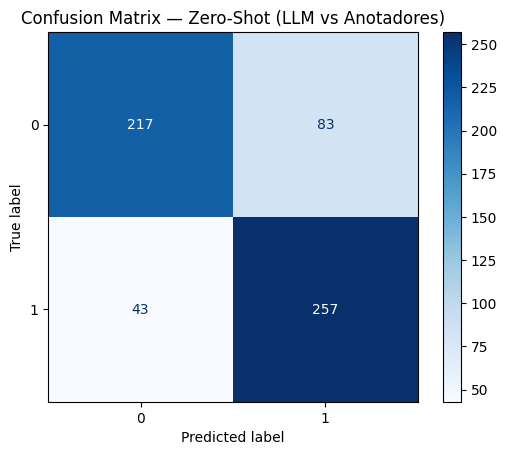

In [23]:

# Lê o arquivo combinado
df = pd.read_csv("./resultados/telegram/telegram_comparado_zeroShot.csv")

# Converte as colunas para inteiro
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_chatgpt"] = pd.to_numeric(df["rotulo_chatgpt"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna(subset=["preconceito", "rotulo_chatgpt"])

y_true = df["preconceito"].values
y_pred = df["rotulo_chatgpt"].values

# Parâmetros do bootstrap
n_bootstrap = 1000  # número de repetições
rng = np.random.default_rng(42)

# Armazena métricas de cada repetição
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# Calcula média e desvio padrão
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)


# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Zero-Shot (LLM vs Anotadores)")
plt.savefig("./resultados/telegram/matriz_confusao_zero_shot.png", dpi=300, bbox_inches="tight")
plt.show()

# Salva os resultados
with open("./resultados/telegram/metricas_avaliacao_zeroShot_bootstrap.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")


### Few Shot

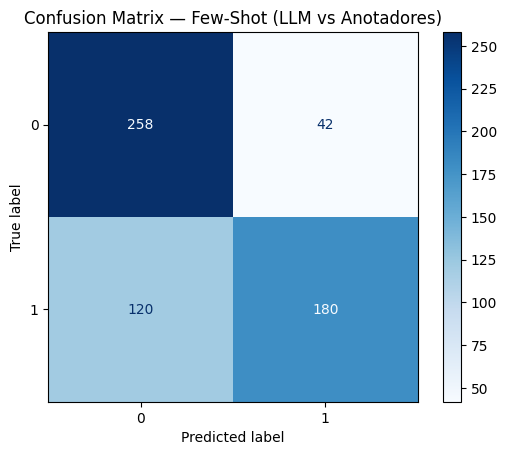


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.7303 ± 0.0181
Precision: 0.8115 ± 0.0262
Recall: 0.6009 ± 0.0288
F1: 0.6900 ± 0.0231
Auc: 0.7305 ± 0.0173


In [24]:

# Lê o arquivo combinado
df = pd.read_csv("./resultados/telegram/telegram_comparado_fewShot.csv")

# Converte as colunas para inteiro
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_chatgpt"] = pd.to_numeric(df["rotulo_chatgpt"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna(subset=["preconceito", "rotulo_chatgpt"])

y_true = df["preconceito"].values
y_pred = df["rotulo_chatgpt"].values

# Parâmetros do bootstrap
n_bootstrap = 1000  # número de repetições
rng = np.random.default_rng(42)

# Armazena métricas de cada repetição
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# Calcula média e desvio padrão
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)

# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Few-Shot (LLM vs Anotadores)")
plt.savefig("./resultados/telegram/matriz_confusao_few_shot.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# Salva os resultados
with open("./resultados/telegram/metricas_avaliacao_fewShot_bootstrap.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")


### Role Prompting

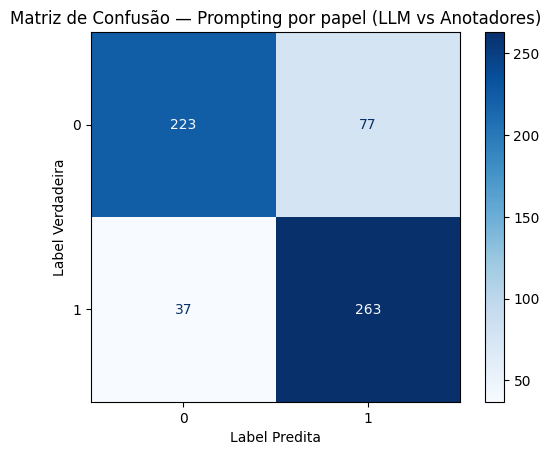


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.8101 ± 0.0164
Precision: 0.7740 ± 0.0224
Recall: 0.8767 ± 0.0193
F1: 0.8219 ± 0.0163
Auc: 0.8100 ± 0.0164


In [25]:

# Lê o arquivo combinado
df = pd.read_csv("./resultados/telegram/telegram_comparado_role_prompting.csv")

# Converte as colunas para inteiro
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_chatgpt"] = pd.to_numeric(df["rotulo_chatgpt"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna(subset=["preconceito", "rotulo_chatgpt"])

y_true = df["preconceito"].values
y_pred = df["rotulo_chatgpt"].values

# Parâmetros do bootstrap
n_bootstrap = 1000  # número de repetições
rng = np.random.default_rng(42)

# Armazena métricas de cada repetição
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# Calcula média e desvio padrão
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)

# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
# Alterando os nomes dos eixos
disp.ax_.set_xlabel("Label Predita")
disp.ax_.set_ylabel("Label Verdadeira")
plt.title("Matriz de Confusão — Prompting por papel (LLM vs Anotadores)")
plt.savefig("./resultados/telegram/matriz_confusao_role_prompting_gpt_telegram.png", dpi=300, bbox_inches="tight")
plt.show()


print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# Salva os resultados
with open("./resultados/telegram/metricas_avaliacao_role_prompting_bootstrap.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")


## Ingles role prompting

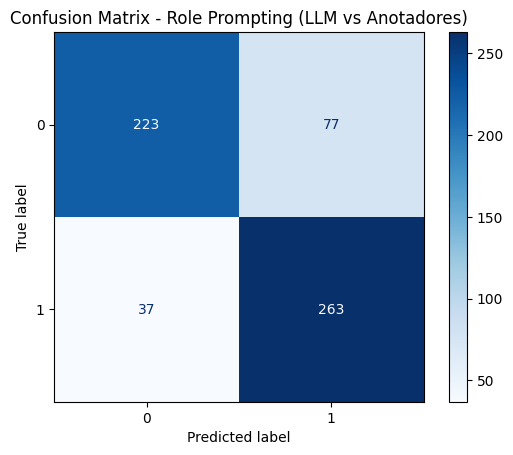


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.8101 ± 0.0164
Precision: 0.7740 ± 0.0224
Recall: 0.8767 ± 0.0193
F1: 0.8219 ± 0.0163
Auc: 0.8100 ± 0.0164


In [3]:

# Lê o arquivo combinado
df = pd.read_csv("./resultados/telegram/telegram_comparado_role_prompting.csv")

# Converte as colunas para inteiro
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_chatgpt"] = pd.to_numeric(df["rotulo_chatgpt"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna(subset=["preconceito", "rotulo_chatgpt"])

y_true = df["preconceito"].values
y_pred = df["rotulo_chatgpt"].values

# Parâmetros do bootstrap
n_bootstrap = 1000  # número de repetições
rng = np.random.default_rng(42)

# Armazena métricas de cada repetição
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# Calcula média e desvio padrão
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)


# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
# Alterando os nomes dos eixos
disp.ax_.set_xlabel("Predicted label")
disp.ax_.set_ylabel("True label")
plt.title("Confusion Matrix - Role Prompting (LLM vs Anotadores)")
plt.savefig("./resultados/telegram/matriz_confusao_role_prompting_deeepseek_ingles_telegram.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# Salva os resultados
with open("./resultados/telegram/metricas_avaliacao_role_prompting_bootstrap.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")


### DICIONÁRIO

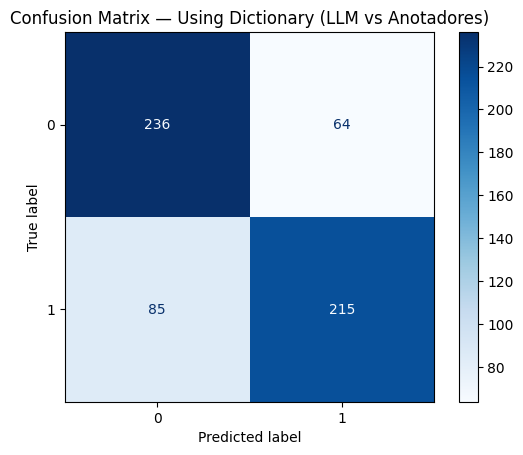


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.7516 ± 0.0175
Precision: 0.7709 ± 0.0252
Recall: 0.7165 ± 0.0253
F1: 0.7424 ± 0.0199
Auc: 0.7516 ± 0.0174


In [26]:

# Lê o arquivo combinado
df = pd.read_csv("./resultados/telegram/telegram_comparado_dicionario.csv")

# Converte as colunas para inteiro
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_chatgpt"] = pd.to_numeric(df["rotulo_chatgpt"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna(subset=["preconceito", "rotulo_chatgpt"])

y_true = df["preconceito"].values
y_pred = df["rotulo_chatgpt"].values

# Parâmetros do bootstrap
n_bootstrap = 1000  # número de repetições
rng = np.random.default_rng(42)

# Armazena métricas de cada repetição
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# Calcula média e desvio padrão
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)

# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Using Dictionary (LLM vs Anotadores)")
plt.savefig("./resultados/telegram/matriz_confusao_role_prompting_dic.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# Salva os resultados
with open("./resultados/telegram/metricas_avaliacao_role_prompting_dic_2_bootstrap.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")


# fold 5

In [7]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =====================================================
# PROMPT
# =====================================================

with open("../datasets/prompt_role_prompting.txt", "r", encoding="utf-8") as f:
    PROMPT_ROLE = f.read()

# =====================================================
# RESULTADOS DAS EXECUÇÕES
# =====================================================

results = []

# =====================================================
# 5 EXECUÇÕES
# =====================================================

for run in range(1, 6):

    print(f"\n==============================")
    print(f"EXECUÇÃO {run}")
    print(f"==============================")

    inicio_total = time.time()

    # =================================================
    # PROCESSAR PARTES
    # =================================================

    for i in range(1, 13):

        entrada = f"../datasets/telegram/parte_{i}_telegram.csv"

        saida = (
            f"./resultados/telegram/"
            f"run_{run}_parte_{i}.csv"
        )

        processar_arquivo(
            entrada,
            saida,
            PROMPT_ROLE,
            "./resultados/telegram/role_prompting_log_processamento.txt"
        )

    # =================================================
    # AQUI VOCÊ DEVE GERAR O ARQUIVO COMPARADO
    # (caso tenha uma função para isso)
    # =================================================

    # Exemplo:
    # gerar_arquivo_comparado(run)

    # =================================================
    # LER ARQUIVO FINAL DA EXECUÇÃO
    # =================================================

    df = pd.read_csv(
        "./resultados/telegram/telegram_comparado_role_prompting.csv"
    )

    # =================================================
    # PREPARAÇÃO
    # =================================================

    df["preconceito"] = pd.to_numeric(
        df["preconceito"],
        errors="coerce"
    )

    df["rotulo_chatgpt"] = pd.to_numeric(
        df["rotulo_chatgpt"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["preconceito", "rotulo_chatgpt"]
    )

    y_true = df["preconceito"].values
    y_pred = df["rotulo_chatgpt"].values

    # =================================================
    # MÉTRICAS
    # =================================================

    acc = accuracy_score(y_true, y_pred)

    prec = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(y_true, y_pred)

    # =================================================
    # SALVAR RESULTADOS
    # =================================================

    results.append({
        "run": run,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc
    })

    # =================================================
    # MATRIZ DE CONFUSÃO
    # =================================================

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["0", "1"]
    )

    disp.plot(
        cmap="Blues",
        values_format="d"
    )

    disp.ax_.set_xlabel("Label Predita")
    disp.ax_.set_ylabel("Label Verdadeira")

    plt.title(
        f"Matriz de Confusão — Run {run}"
    )

    plt.savefig(
        f"./resultados/telegram/matriz_run_{run}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    total_minutos = (
        time.time() - inicio_total
    ) / 60

    print(f"\nRun {run} finalizada")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Tempo: {total_minutos:.2f} min")

# =====================================================
# DATAFRAME FINAL
# =====================================================

results_df = pd.DataFrame(results)

print("\n===================================")
print("RESULTADOS FINAIS")
print("===================================")

print(results_df)

# =====================================================
# MÉDIA E DESVIO PADRÃO
# =====================================================

summary = results_df.describe().loc[
    ["mean", "std"]
]

print("\nResumo:")
print(summary)

# =====================================================
# SALVAR CSV
# =====================================================

results_df.to_csv(
    "./resultados/telegram/llm_role_prompting_runs.csv",
    index=False
)

summary.to_csv(
    "./resultados/telegram/llm_role_prompting_summary.csv"
)

print("\nArquivos salvos com sucesso!")


EXECUÇÃO 1

Processando ../datasets/telegram/parte_1_telegram.csv -> ./resultados/telegram/run_1_parte_1.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/run_1_parte_1.csv
Tempo total: 0.06 min | Tokens total: 5832

Processando ../datasets/telegram/parte_2_telegram.csv -> ./resultados/telegram/run_1_parte_2.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/run_1_parte_2.csv
Tempo total: 0.05 min | Tokens total: 5876

Processando ../datasets/telegram/parte_3_telegram.csv -> ./resultados/telegram/run_1_parte_3.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/run_1_parte_3.csv
Tempo total: 0.05 min | Tokens total: 4892

Processando ../datasets/telegram/parte_4_telegram.csv -> ./resultados/telegram/run_1_parte_4.csv
Lote 1/1 - 50 textos
Arquivo salvo em ./resultados/telegram/run_1_parte_4.csv
Tempo total: 0.05 min | Tokens total: 5005

Processando ../datasets/telegram/parte_5_telegram.csv -> ./resultados/telegram/run_1_parte_5.csv
Lote 1/1 - 50 